In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# load data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop('customerID', axis=1, inplace=True)

# new features
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['ServiceCount'] = df[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)
df['IsMonthly'] = (df['Contract'] == 'Month-to-month').astype(int)

# encode
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols)

# prepare data
x = df.drop('Churn', axis=1)
y = df['Churn']
scaler = StandardScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)

# balance and split
sm = SMOTE(random_state=42)
x_bal, y_bal = sm.fit_resample(x_scaled, y)
x_train, x_temp, y_train, y_temp = train_test_split(
    x_bal, y_bal, test_size=0.30, random_state=42, stratify=y_bal)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# train best model (random forest)
best_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
best_rf.fit(x_train, y_train)

print("Setup done!")

/tmp/ipykernel_6039/1904901261.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


Setup done!


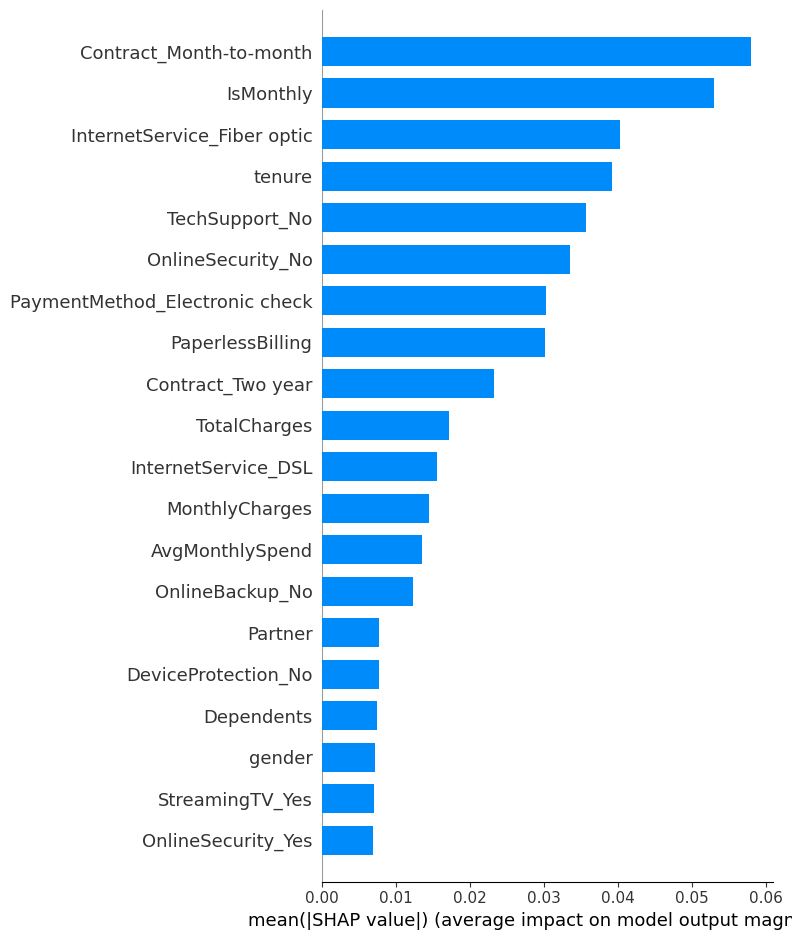

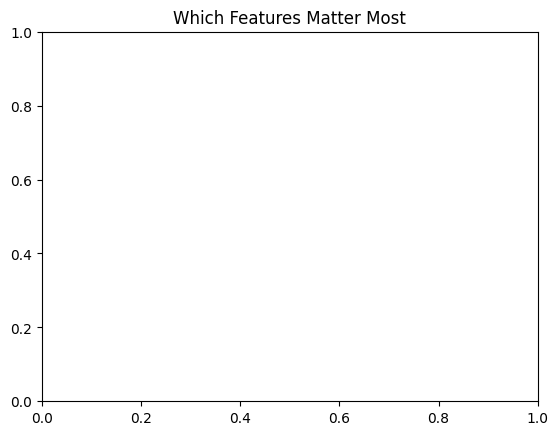

In [6]:
# shap helps us understand why model made a decision
explainer = shap.TreeExplainer(best_rf)

# take 100 customers as sample
sample = x_test.iloc[:100]
shap_values = explainer.shap_values(sample)

# show which features matter most overall
shap.summary_plot(shap_values[:,:,1], sample, plot_type='bar')
plt.title('Which Features Matter Most')
plt.show()

Why did this customer leave?


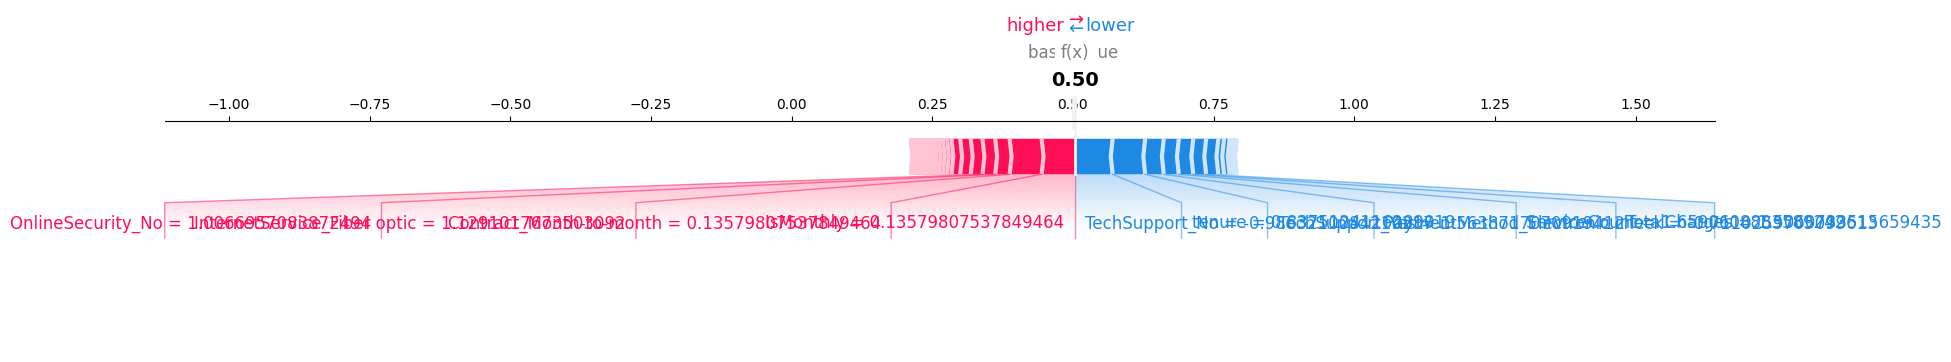

Why did this customer stay?


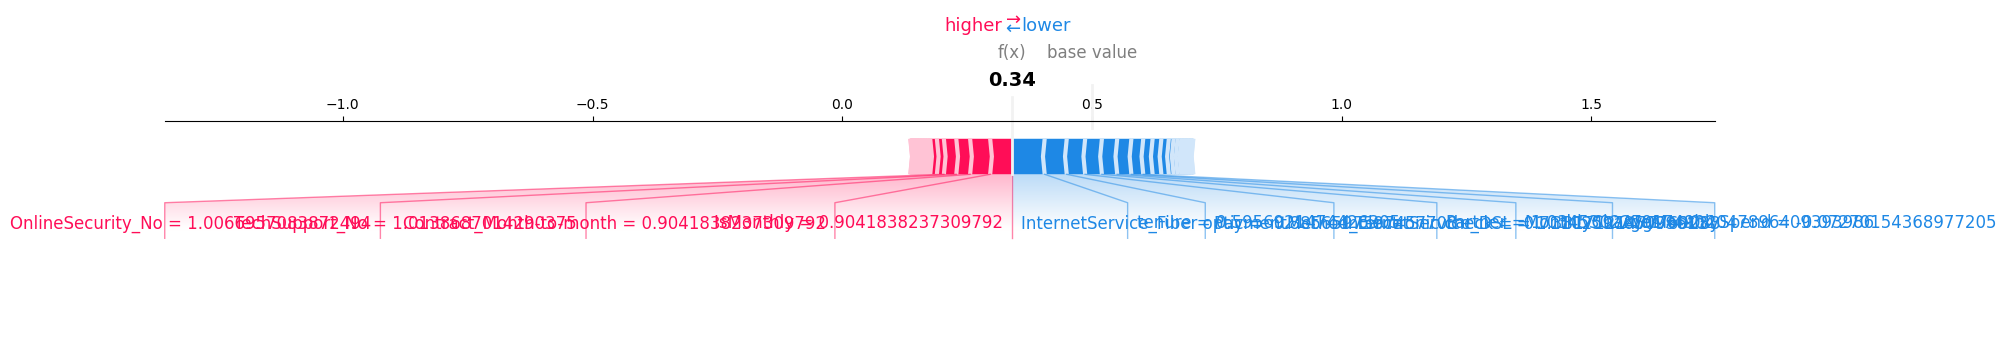

In [7]:
# find one customer who churned
churned_idx = y_test[y_test == 1].index[0]
churned_pos = x_test.index.get_loc(churned_idx)

# find one customer who stayed
retained_idx = y_test[y_test == 0].index[0]
retained_pos = x_test.index.get_loc(retained_idx)

# explain churned customer
print("Why did this customer leave?")
shap.force_plot(explainer.expected_value[1],
                shap_values[churned_pos,:,1],
                x_test.iloc[churned_pos],
                matplotlib=True)
plt.show()

# explain retained customer
print("Why did this customer stay?")
shap.force_plot(explainer.expected_value[1],
                shap_values[retained_pos,:,1],
                x_test.iloc[retained_pos],
                matplotlib=True)
plt.show()

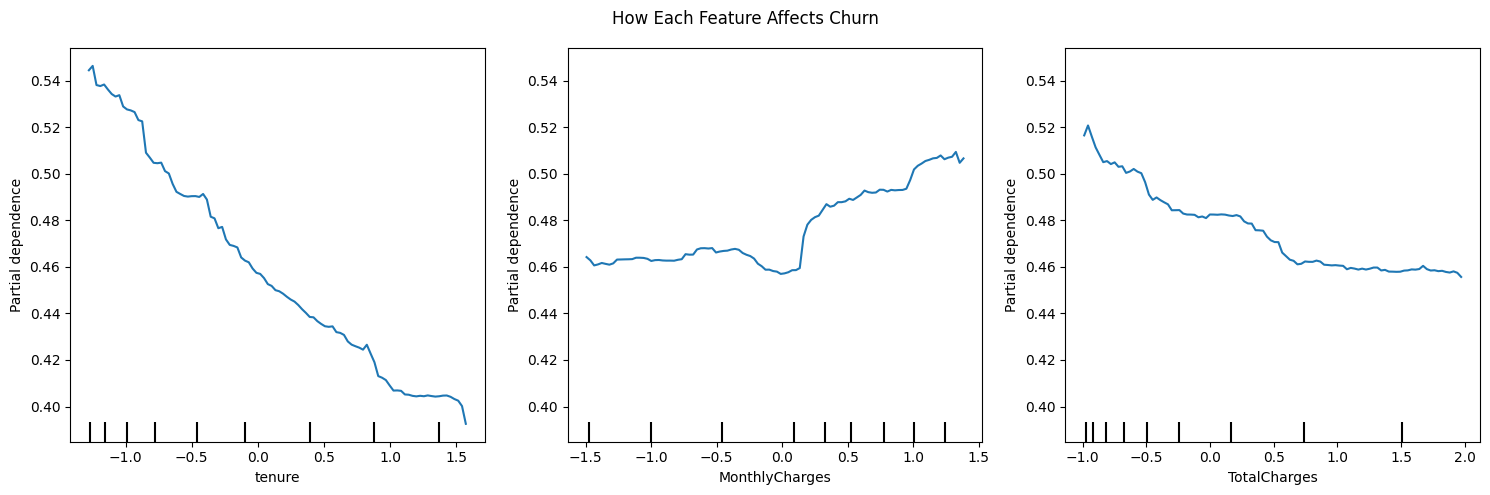

In [8]:
from sklearn.inspection import PartialDependenceDisplay

# see how top 3 features affect churn
top_3 = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
PartialDependenceDisplay.from_estimator(best_rf, x_train, top_3, ax=axes)
plt.suptitle('How Each Feature Affects Churn')
plt.tight_layout()
plt.show()

In [12]:
print("BUSINESS RECOMMENDATIONS")
print("========================")

print("\n1. TOP 5 REASONS CUSTOMERS LEAVE:")
print("   - New customers leave within first 12 months")
print("   - Month to month contract customers have no reason to stay")
print("   - Customers paying high charges look for cheaper options")
print("   - Fiber optic users are not satisfied with the service")
print("   - Customers with no security addons are less engaged")

print("\n2. WHO IS MOST LIKELY TO LEAVE:")
print("   - Customers who joined less than 12 months ago")
print("   - Customers on monthly contracts")
print("   - Customers paying more than 70 per month")
print("   - Senior citizens without tech support")

print("\n3. PRICING SUGGESTIONS:")
print("   - Give discounts to customers who pay too much")
print("   - Create service bundles at lower price")
print("   - Give loyalty rewards to long term customers")

print("\n4. IF WE CAN ONLY SAVE 100 CUSTOMERS:")
print("   - Pick top 100 customers with highest churn probability")
print("   - Focus more on monthly contract customers")
print("   - Contact them with special offers before they leave")

BUSINESS RECOMMENDATIONS

1. TOP 5 REASONS CUSTOMERS LEAVE:
   - New customers leave within first 12 months
   - Month to month contract customers have no reason to stay
   - Customers paying high charges look for cheaper options
   - Fiber optic users are not satisfied with the service
   - Customers with no security addons are less engaged

2. WHO IS MOST LIKELY TO LEAVE:
   - Customers who joined less than 12 months ago
   - Customers on monthly contracts
   - Customers paying more than 70 per month
   - Senior citizens without tech support

3. PRICING SUGGESTIONS:
   - Give discounts to customers who pay too much
   - Create service bundles at lower price
   - Give loyalty rewards to long term customers

4. IF WE CAN ONLY SAVE 100 CUSTOMERS:
   - Pick top 100 customers with highest churn probability
   - Focus more on monthly contract customers
   - Contact them with special offers before they leave


In [13]:
# how many customers are in test set
total = len(y_test)
# how many actually left
actual_left = y_test.sum()
# how many our model correctly caught
model_caught = ((best_rf.predict(x_test) == 1) & (y_test == 1)).sum()

# money values
retention_cost = 50      # cost to save one customer
churn_loss = 500         # money lost if customer leaves

# without model - random guessing
random_hit = int(100 * actual_left / total)
random_saved = random_hit * churn_loss
random_spent = 100 * retention_cost
random_profit = random_saved - random_spent

# with our model
model_saved = model_caught * churn_loss
model_spent = 100 * retention_cost
model_profit = model_saved - model_spent

print("WITHOUT MODEL (random guessing):")
print("  Money spent:", random_spent)
print("  Money saved:", random_saved)
print("  Net profit:", random_profit)

print("\nWITH OUR MODEL:")
print("  Money spent:", model_spent)
print("  Money saved:", model_saved)
print("  Net profit:", model_profit)

print("\nExtra profit by using model:", model_profit - random_profit)

WITHOUT MODEL (random guessing):
  Money spent: 5000
  Money saved: 24500
  Net profit: 19500

WITH OUR MODEL:
  Money spent: 5000
  Money saved: 343000
  Net profit: 338000

Extra profit by using model: 318500
